# Experiment A-04 - Seed-Dependence with long (365 days) Spinups

## **🔴 Context**

- Experiment A-03 revealed that trained schemes depend strongly on the seed: independently
  trained schemes learned measurably different mappings.
- This could be due to too strong initial pertubation or too short spinup times.
- New z-score statistics and reference data were generated with a 12× longer spinup (365 days).


---

## **🟡 Experiment Questions**

#### **Q1 - How does longer spinups (10x) affect scheme performance?**

No. Within the corrected setup the schemes remain clearly imperfect: day-31 T RMSE is
still ~3 K against a target that is 0 by construction. The training loss still reaches its
floor inside the first initial condition. The spinup fix improved reproducibility, not
absolute skill.

#### **Q1 - How does longer spinups (10x) affect seed dependence?**

Area-weighted median day-1 correlation, `Day(365)` vs `Day(30)`:

| field | Day(365) | Day(30) |
|---|---|---|
| Temperature | **0.725** | 0.468 |
| olw         | 0.579 | 0.599 |
| slwd        | 0.795 | 0.792 |

Temperature reproducibility improves substantially; the flux mappings are unchanged.


---


## **🟢 Short Result**
#### No improvements in scheme performances. High improvements for temperature forecast correlation, no improvement for olw or slwd correlation.


---

## **0. Setup**

In [64]:
# Loading packages
using Revise
using NeuralParam
using CairoMakie
using Statistics

In [65]:
# Define experiment
EXP = "exp_A_04_seeding_spinup"

"exp_A_04_seeding_spinup"

## **1. Training**

In [66]:
# Define notebook picture scaling
NB_TRAIN = (; size = (900, 600));

In [67]:
# Define experiment and schemes
SCHEMES = ["NLW_direct", "NLW_linear", "NLW_seed1", "NLW_seed2", "NLW_seed3"]
LABELS = ["Direct", "Linear", "Seed 1", "Seed 2", "Seed 3"]
COLORS = [JL_RED, JL_BLUE, JL_GREEN, JL_GREEN, JL_GREEN];
STEPS = 100:500;

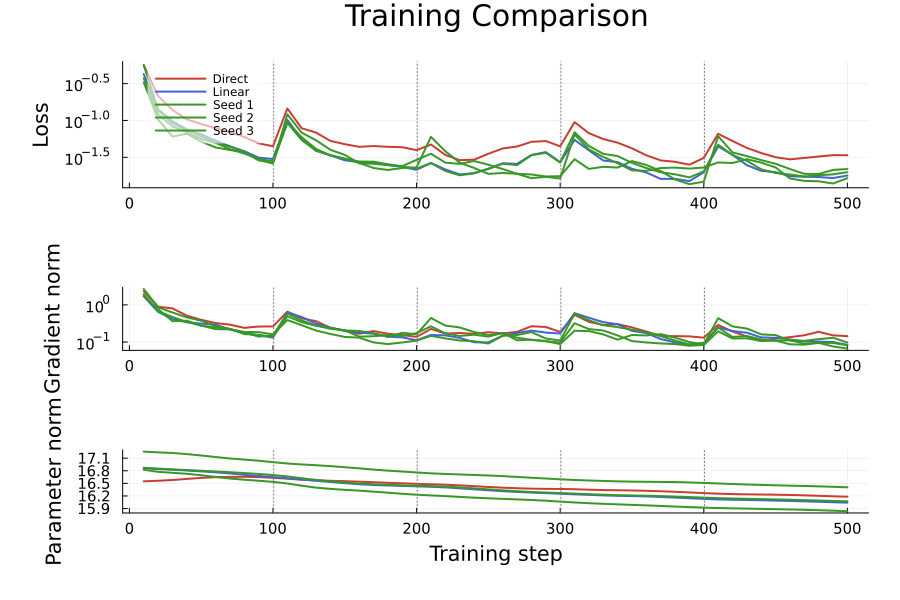

In [68]:
# Plot training comparison
plot_training_comp(; exp = EXP, names = SCHEMES, labels = LABELS, colors = COLORS, plot_kwargs = NB_TRAIN)

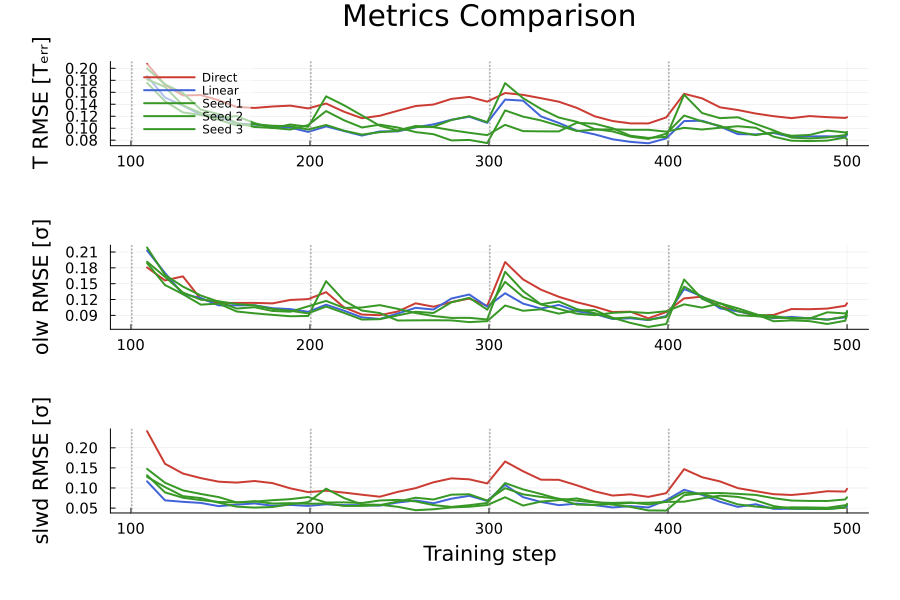

In [69]:
# Training metrics comparison
plot_metrics_comp(; exp = EXP, names = SCHEMES, labels = LABELS, colors = COLORS, steps = STEPS, plot_kwargs = NB_TRAIN)

## **2. Rollouts**

In [70]:
# Define notebook picture scaling
NB_ROLLOUT = (; size = (1200, 400));

In [ ]:
# Load different seeded NeuralLW scheme with Planck output rollouts
SKILL_NAMES = [
    "OBLW_skill",
    "NLW_direct_skill",
    "NLW_seed1_skill", 
    "NLW_seed2_skill", 
    "NLW_seed3_skill", 
]
STAB_NAMES = replace.(SKILL_NAMES, "skill" => "stab")

skill = collect_rollouts(EXP, SKILL_NAMES)
stab = collect_rollouts(EXP, STAB_NAMES);

In [72]:
# Define labels and colors
LABELS = ["OBLW", "NLW direct", "NLW Seed 1", "NLW Seed 2", "NLW Seed 3"];
COLORS = [:grey, :black, JL_RED, JL_RED, JL_RED];

### 2.1. Skill - Correlation (31 days)

#### 2.1.1 Time Series

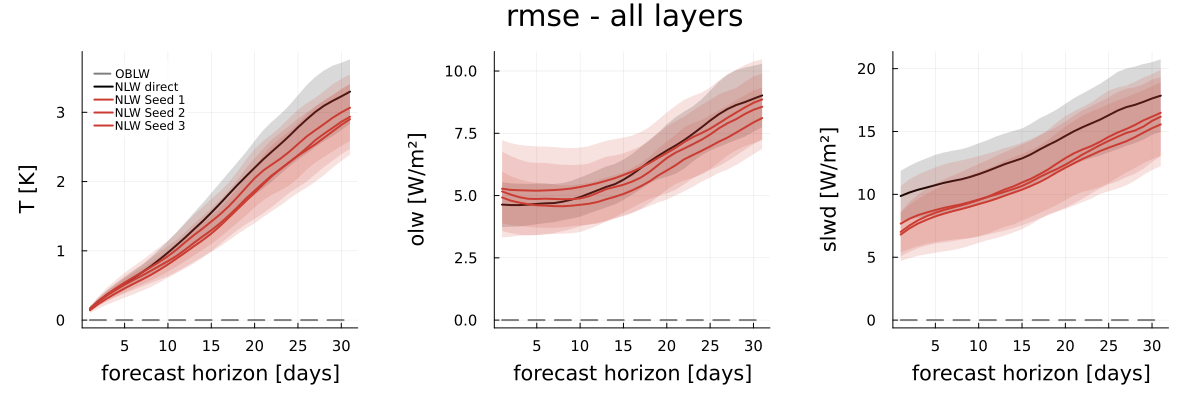

In [73]:
# Plot rmse comparison
plot_rollout(rollouts = skill, metric = :rmse, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

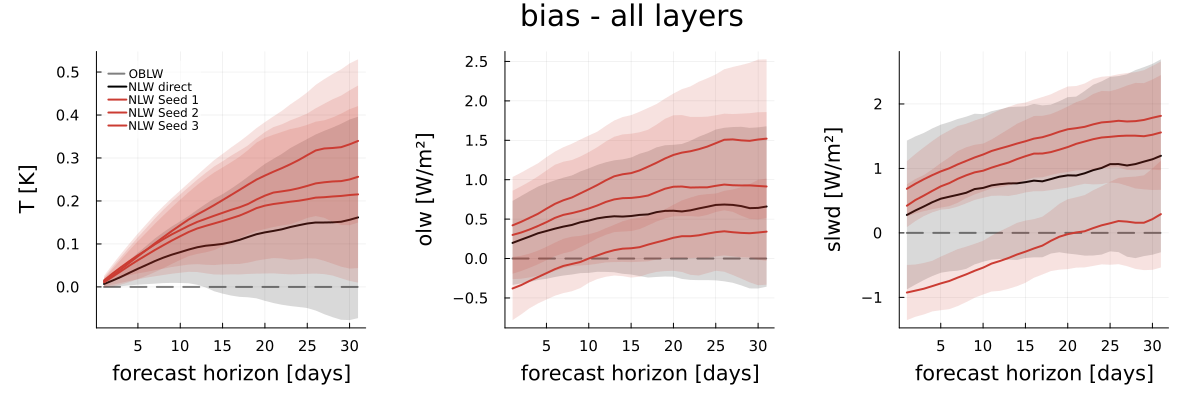

In [74]:
# Plot bias comparison
plot_rollout(rollouts = skill, metric = :bias, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

In [ ]:
# Plot maxdiff comparison
plot_rollout(rollouts = skill, metric = :maxdiff, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

#### 2.1.2. Heatmaps

In [ ]:
# Define notebook picture scaling
NB_HM = (; width = 400, height = 200, titlesize = 16, suptitlesize = 20);

In [ ]:
# Heatmap temperature surface layer
plot_rollout_heatmaps(; rollouts = skill, var = :T, ref = :OBLW_skill, layer = 8, labels = LABELS, layout = :horizontal, NB_HM...)[5]

In [ ]:
# Heatmap temperature mid layer
plot_rollout_heatmaps(; rollouts = skill, var = :T, ref = :OBLW_skill, layer = 4, labels = LABELS, layout = :horizontal, NB_HM...)[5]

In [ ]:
# Heatmap temperature upper layer
plot_rollout_heatmaps(; rollouts = skill, var = :T, ref = :OBLW_skill, layer = 1, labels = LABELS, layout = :horizontal, NB_HM...)[5]

In [ ]:
# Heatmap outgoing LW radiation
plot_rollout_heatmaps(; rollouts = skill, var = :olw, ref = :OBLW_skill, labels = LABELS, layout = :horizontal, NB_HM...)[5]

In [ ]:
# Heatmap outgoing LW radiation
plot_rollout_heatmaps(; rollouts = skill, var = :slwd, ref = :OBLW_skill, labels = LABELS, layout = :horizontal, NB_HM...)[5]

#### 2.1.3 Correlation

In [ ]:
# Variable correlation after 1 day 
print_correlation(; rollouts = skill, day = 1, var = (:T, :olw, :slwd), labels = LABELS)

In [ ]:
# Variable correlation after 7 days
print_correlation(; rollouts = skill, day = 7, var = (:T, :olw, :slwd), labels = LABELS)

In [ ]:
# Variable correlation after 31 days
print_correlation(; rollouts = skill, day = 31, var = (:T, :olw, :slwd), labels = LABELS)

### 2.2 Spinup Comparison (skill of 30 days vs 365 days spinup)

In [ ]:
# Load for comparison NeuralLW scheme with different spinup time (30 days)
EXP_SHORT_SU = "exp_A_02_NLW_outputForms";
skill_SHORT_SU = collect_rollouts(EXP_SHORT_SU, ["NLW_planck_skill"]);
stab_SHORT_SU = collect_rollouts(EXP_SHORT_SU, ["NLW_planck_stab"]);

In [ ]:
# Define rollouts
SKILL_NAMES = [
    "OBLW_skill",
    "NLW_seed1_skill", 
    "NLW_seed2_skill", 
    "NLW_seed3_skill", 
]
STAB_NAMES = replace.(SKILL_NAMES, "skill" => "stab")

skill_SEED = collect_rollouts(EXP, SKILL_NAMES);
stab_SEED = collect_rollouts(EXP, STAB_NAMES);

In [ ]:
# Merge rollouts and define labels and colors
skill = merge(skill_SHORT_SU, skill_SEED)
stab = merge(stab_SHORT_SU, stab_SEED)


LABELS = ["Short Spinup", "OBLW", "NLW Seed 1", "NLW Seed 2", "NLW Seed 3"]
COLORS = [:black, :grey, JL_RED, JL_RED, JL_RED];

#### 2.2.1 Skill Time Series (31 days)

In [ ]:
# Plot rmse comparison
plot_rollout(rollouts = skill, metric = :rmse, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

In [ ]:
# Plot bias comparison
plot_rollout(rollouts = skill, metric = :bias, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

In [ ]:
# Plot maxdiff comparison
plot_rollout(rollouts = skill, metric = :maxdiff, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

#### 2.2.2 Stability Time Series (365 days)

In [ ]:
# Plot rmse comparison
plot_rollout(rollouts = stab, metric = :rmse, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

In [ ]:
# Plot bias comparison
plot_rollout(rollouts = stab, metric = :bias, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

In [ ]:
# Plot maxdiff comparison
plot_rollout(rollouts = stab, metric = :maxdiff, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)